# NGC4698 electron-density maps from corrected [S II] fluxes

**29 September 2026.** Read the corrected [S II] flux maps from
`NGC4698_gas_bin_maps_further.fits`, calculate their ratio and an exploratory
PyNeb electron-density map at an assumed 10,000 K, and display the ratio,
density, quality categories, and `NE_SII_ALL` in this notebook. No FITS or
image files are written.

The FITS product names the second line `SII6730`; PyNeb identifies the same
[S II] doublet member as 6731 Angstrom. This notebook uses the corrected flux
extensions without an S/N cut. Corrected error maps exist in the input file,
but are not used here, matching the source notebook's finite-positive selection.
The resulting maps are exploratory and have no propagated density errors.


## 0. Input and scientific choices

- Input: `NGC4698_gas_bin_maps_further.fits`.
- Flux extensions: `SII6716_FLUX_CORR` and `SII6730_FLUX_CORR` (integrated
  corrected fluxes, both in `1e-20 erg s-1 cm-2`).
- Ratio: $R=F(6716)/F(6730)$, conventionally called [S II] 6716/6731.
- Physics: PyNeb S II atom, $T_e=10,000$ K, and a 4,096-point density grid
  from 20 to 100,000 cm$^{-3}$.
- Selection: finite positive values in both corrected flux maps. This is not
  an S/N selection even though corrected error extensions are available.

Ratios above PyNeb's physical low-density limit are invalid. Ratios between
that limit and the 20 cm$^{-3}$ grid edge receive a flagged 20 cm$^{-3}$
floor. Ratios below the high-density grid edge are invalid. The output is
displayed only; no product is saved to disc.


In [1]:
from pathlib import Path

import astropy
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap, LogNorm
from matplotlib.patches import Patch
import numpy as np
import pyneb as pn
from astropy.io import fits
from astropy.wcs import WCS

INPUT_FILE = Path(
    "/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8/NGC4698/"
    "NGC4698_gas_bin_maps_further.fits"
)
SII6716_HDU = "SII6716_FLUX_CORR"
SII6730_HDU = "SII6730_FLUX_CORR"
LOOKUP_FILE = Path(
    "/Users/Igniz/Desktop/ICRAR/NGC4698/"
    "pyneb_sii_6716_6731_density_lookup_"
    "te8000_13000_step1000_ne20_100000_n4096.npz"
)

TE_K = 10_000.0
NE_MIN_CM3 = 20.0
NE_MAX_CM3 = 100_000.0
N_GRID = 4096
MIN_LINE_VALUE = 0.0  # Optional corrected-flux floor, not an S/N threshold.

if not INPUT_FILE.is_file():
    raise FileNotFoundError(INPUT_FILE)
print("Python dependencies:",
      "NumPy", np.__version__,
      "Astropy", astropy.__version__,
      "PyNeb", pn.__version__,
      "Matplotlib", matplotlib.__version__)
print("Input:", INPUT_FILE)
print("Corrected flux extensions:", SII6716_HDU, "and", SII6730_HDU)


Python dependencies: NumPy 2.2.6 Astropy 7.0.2 PyNeb 1.1.30 Matplotlib 3.10.3
Input: /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8/NGC4698/NGC4698_gas_bin_maps_further.fits
Corrected flux extensions: SII6716_FLUX_CORR and SII6730_FLUX_CORR


## 1. Load the corrected maps and verify their grids

FITS data are indexed as `[y, x]`. The two named HDUs must have matching
shapes, units, and celestial WCS so the pixel ratio is meaningful.


In [2]:
with fits.open(INPUT_FILE, memmap=True) as hdul:
    flux_6716 = np.asarray(hdul[SII6716_HDU].data, dtype=np.float64)
    flux_6731 = np.asarray(hdul[SII6730_HDU].data, dtype=np.float64)
    header_6716 = hdul[SII6716_HDU].header.copy()
    header_6731 = hdul[SII6730_HDU].header.copy()

if flux_6716.ndim != 2 or flux_6716.shape != flux_6731.shape:
    raise ValueError("Both corrected [S II] inputs must be matching 2-D maps")
if header_6716.get("BUNIT") != header_6731.get("BUNIT"):
    raise ValueError("The corrected [S II] maps have different recorded units")

wcs_6716 = WCS(header_6716).celestial
wcs_6731 = WCS(header_6731).celestial
ny, nx = flux_6716.shape
probe_x = np.array([0, nx // 2, nx - 1], dtype=float)
probe_y = np.array([0, ny // 2, ny - 1], dtype=float)
sky_6716 = wcs_6716.pixel_to_world_values(probe_x, probe_y)
sky_6731 = wcs_6731.pixel_to_world_values(probe_x, probe_y)
if not all(np.allclose(a, b, rtol=0, atol=1e-8)
           for a, b in zip(sky_6716, sky_6731)):
    raise ValueError("The corrected input celestial WCS grids differ")

print(f"Shape: {ny} rows x {nx} columns")
print("Input BUNIT:", header_6716["BUNIT"])
print("Finite, positive pixels:",
      np.count_nonzero(np.isfinite(flux_6716) & (flux_6716 > 0)),
      "at 6716 and",
      np.count_nonzero(np.isfinite(flux_6731) & (flux_6731 > 0)),
      "at 6730")


Shape: 1189 rows x 608 columns
Input BUNIT: 1e-20 erg s-1 cm-2
Finite, positive pixels: 352493 at 6716 and 351968 at 6730


## 2. Form the corrected-flux doublet ratio

Require finite positive corrected fluxes in both maps. `MIN_LINE_VALUE`
can impose an extra flux cut, but it is not an S/N threshold. Missing,
nonpositive, or excluded pixels remain NaN.


In [3]:
usable = (
    np.isfinite(flux_6716) & np.isfinite(flux_6731)
    & (flux_6716 > MIN_LINE_VALUE)
    & (flux_6731 > MIN_LINE_VALUE)
)
ratio = np.full(flux_6716.shape, np.nan, dtype=np.float64)
np.divide(flux_6716, flux_6731, out=ratio, where=usable)
usable &= np.isfinite(ratio) & (ratio > 0)
ratio[~usable] = np.nan

print(f"Pixels with both usable lines: {np.count_nonzero(usable):,}")
print("Observed ratio percentiles (1, 50, 99):",
      np.nanpercentile(ratio, [1, 50, 99]))

Pixels with both usable lines: 351,954
Observed ratio percentiles (1, 50, 99): [0.76161558 1.42861664 3.7227319 ]


## 3. Display the corrected [S II] ratio map

Gray marks pixels without two finite positive corrected fluxes. Colours span
the 1st to 99th percentiles of valid ratios; clipping is for display only.
No S/N cut is applied.


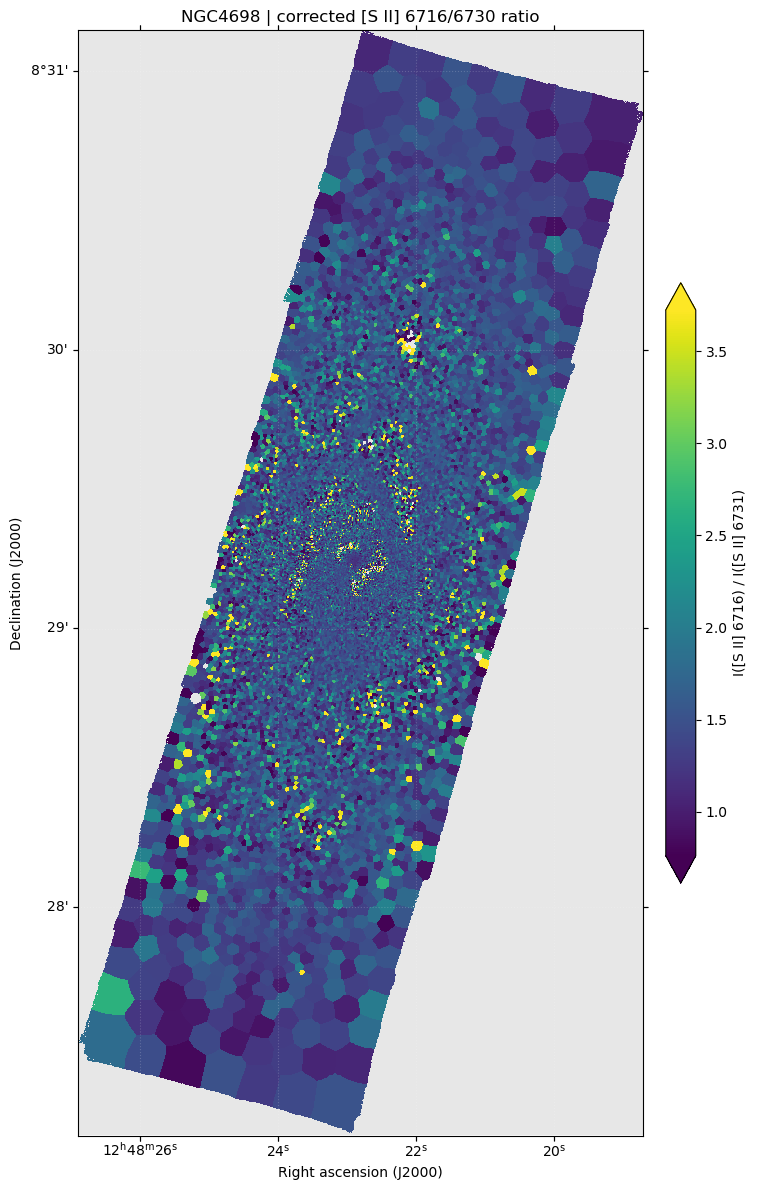

Ratio display range (1st-99th percentile): 0.762 to 3.723


In [4]:
ratio_pixels = np.isfinite(ratio)
if not np.any(ratio_pixels):
    raise ValueError("No valid [S II] line ratios to display")
ratio_vmin, ratio_vmax = np.nanpercentile(ratio, [1, 99])
if not ratio_vmax > ratio_vmin:
    raise ValueError("The ratio display range is degenerate")
ratio_cmap = plt.get_cmap("viridis").copy()
ratio_cmap.set_bad("#e7e7e7")

fig = plt.figure(figsize=(9, 12))
ax = fig.add_subplot(111, projection=wcs_6716)
image = ax.imshow(
    np.ma.masked_invalid(ratio), origin="lower",
    cmap=ratio_cmap, vmin=ratio_vmin, vmax=ratio_vmax,
    interpolation="nearest",
)
ax.set_title("NGC4698 | corrected [S II] 6716/6730 ratio")
ax.coords[0].set_axislabel("Right ascension (J2000)")
ax.coords[1].set_axislabel("Declination (J2000)")
ax.coords.grid(color="white", alpha=0.18, linestyle=":")
colorbar = fig.colorbar(image, ax=ax, fraction=0.04, pad=0.03,
                        extend="both")
colorbar.set_label("I([S II] 6716) / I([S II] 6731)")
fig.tight_layout()
plt.show()
print(f"Ratio display range (1st-99th percentile): "
      f"{ratio_vmin:.3f} to {ratio_vmax:.3f}")

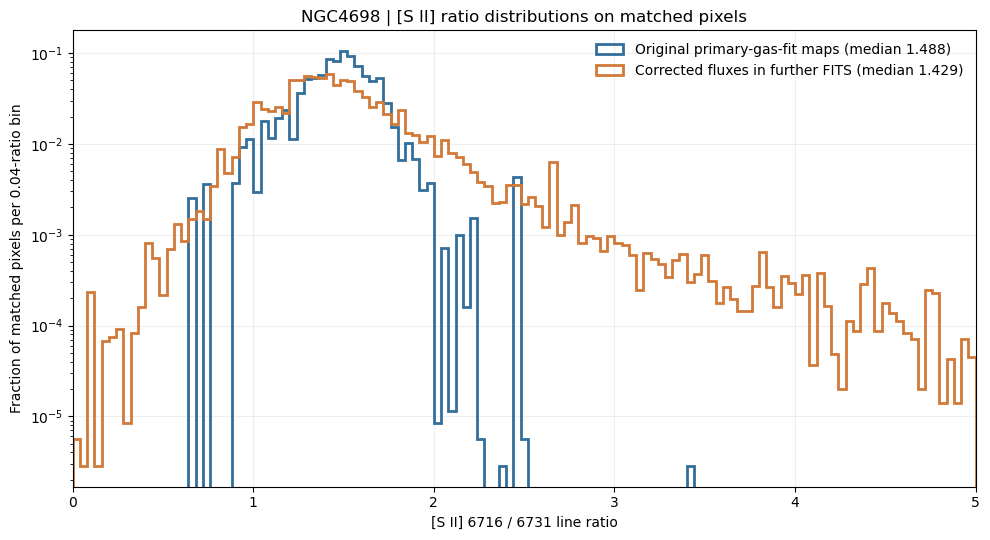

Matched finite-positive pixels: 351,946
Original ratio > 5 (outside plot): 0
Corrected ratio > 5 (outside plot): 1,542
The plotted fractions use all matched pixels as the denominator; the y axis is logarithmic.


In [5]:
# Compare the original primary-fit and corrected-flux ratio distributions.
# Use only pixels with a finite, positive ratio in both inputs.
PRIMARY_6716_FILE = Path(
    "/Users/Igniz/Desktop/ICRAR/NGC4698/flux_map_SII6716_primary_gas_fit.fits"
)
PRIMARY_6731_FILE = Path(
    "/Users/Igniz/Desktop/ICRAR/NGC4698/flux_map_SII6731_primary_gas_fit.fits"
)
with fits.open(PRIMARY_6716_FILE, memmap=True) as hdul:
    primary_6716 = np.asarray(hdul[0].data, dtype=np.float64)
with fits.open(PRIMARY_6731_FILE, memmap=True) as hdul:
    primary_6731 = np.asarray(hdul[0].data, dtype=np.float64)
if primary_6716.shape != ratio.shape or primary_6731.shape != ratio.shape:
    raise ValueError("Primary-fit and corrected maps must share an image shape")

primary_usable = (
    np.isfinite(primary_6716) & np.isfinite(primary_6731)
    & (primary_6716 > MIN_LINE_VALUE)
    & (primary_6731 > MIN_LINE_VALUE)
)
primary_ratio = np.full(ratio.shape, np.nan, dtype=np.float64)
np.divide(primary_6716, primary_6731, out=primary_ratio,
          where=primary_usable)
matched = np.isfinite(primary_ratio) & (primary_ratio > 0) & np.isfinite(ratio)
primary_values = primary_ratio[matched]
corrected_values = ratio[matched]
if primary_values.size == 0:
    raise ValueError("No matched pixels with usable ratios in both inputs")

bins = np.linspace(0, 5, 126)
fig, ax = plt.subplots(figsize=(10, 5.5))
for values, label, color in (
    (primary_values, "Original primary-gas-fit maps", "#326f9b"),
    (corrected_values, "Corrected fluxes in further FITS", "#d17938"),
):
    ax.hist(values, bins=bins,
            weights=np.full(values.size, 1.0 / values.size),
            histtype="step", linewidth=2, color=color,
            label=f"{label} (median {np.median(values):.3f})")
ax.set(xlim=(bins[0], bins[-1]), yscale="log",
       xlabel="[S II] 6716 / 6731 line ratio",
       ylabel="Fraction of matched pixels per 0.04-ratio bin",
       title="NGC4698 | [S II] ratio distributions on matched pixels")
ax.grid(alpha=0.2)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print(f"Matched finite-positive pixels: {matched.sum():,}")
print(f"Original ratio > 5 (outside plot): {np.count_nonzero(primary_values > 5):,}")
print(f"Corrected ratio > 5 (outside plot): {np.count_nonzero(corrected_values > 5):,}")
print("The plotted fractions use all matched pixels as the denominator; "
      "the y axis is logarithmic.")


## 4. Build the PyNeb ratio-to-density relation

The theoretical emissivity ratio is calculated at 10,000 K using the
installed PyNeb atomic data. The optional local NPZ cache is checked only
for provenance. This notebook does not write a lookup file.


In [6]:
sii = pn.Atom("S", 2)
density_grid = np.geomspace(NE_MIN_CM3, NE_MAX_CM3, N_GRID)
emissivity_6716 = np.asarray(
    sii.getEmissivity(tem=TE_K, den=density_grid, wave=6716),
    dtype=float,
)
emissivity_6731 = np.asarray(
    sii.getEmissivity(tem=TE_K, den=density_grid, wave=6731),
    dtype=float,
)
theoretical_ratio = emissivity_6716 / emissivity_6731
if theoretical_ratio.shape != density_grid.shape:
    raise ValueError("Unexpected PyNeb emissivity-grid shape")
if not np.all(np.isfinite(theoretical_ratio)):
    raise ValueError("PyNeb ratio grid contains nonfinite values")
if not np.all(np.diff(theoretical_ratio) < 0):
    raise ValueError("The PyNeb density ratio is not strictly decreasing")

ratio_at_20 = float(theoretical_ratio[0])
ratio_at_100000 = float(theoretical_ratio[-1])
low_density_limit = float(sii.getLowDensRatio(
    wave1=6716, wave2=6731, tem=TE_K
))
if low_density_limit <= ratio_at_20:
    raise ValueError("The physical low-density limit is below the grid edge")

print("PyNeb S II atomic data:", sii.atomFile, "/", sii.collFile)
print(f"R(100,000 cm^-3) = {ratio_at_100000:.6f}")
print(f"R(20 cm^-3) = {ratio_at_20:.6f}")
print(f"Low-density ratio limit = {low_density_limit:.6f}")
if LOOKUP_FILE.is_file():
    with np.load(LOOKUP_FILE, allow_pickle=False) as cache:
        same_grid = np.allclose(cache["density_grid"], density_grid)
        same_temperature = np.isclose(float(cache["selected_tem"]), TE_K)
        cached_ratio = cache["selected_ratio_grid"]
        max_difference = float(np.max(np.abs(
            cached_ratio - theoretical_ratio
        ))) if cached_ratio.shape == theoretical_ratio.shape else np.inf
    print("Existing lookup check:",
          f"same density grid={same_grid},",
          f"same temperature={same_temperature},",
          f"max |Delta R|={max_difference:.3g}")

PyNeb S II atomic data: s_ii_atom_RGJ19.dat / s_ii_coll_TZ10.dat
R(100,000 cm^-3) = 0.447444
R(20 cm^-3) = 1.432332
Low-density ratio limit = 1.454944
Existing lookup check: same density grid=True, same temperature=True, max |Delta R|=1.67e-16


## 5. Invert the ratio and label quality categories

A measured density requires the ratio to lie within the computed 20 to
100,000 cm^-3 relation. Because theoretical ratio decreases with density,
reverse both arrays for NumPy interpolation. The grid-edge category between
R(20 cm^-3) and the physical low-density limit receives 20 cm^-3 as a floor;
it does **not** measure exactly 20 cm^-3. Ratios beyond the physical limit
and beyond the high-density grid remain NaN.

QC codes: 0 = unusable input; 1 = within the PyNeb density grid;
2 = below the 20 cm^-3 floor; 3 = ratio above physical low-density limit;
4 = ratio below the 100,000 cm^-3 grid edge.

In [7]:
qc = np.zeros(ratio.shape, dtype=np.uint8)
measured = usable & (ratio >= ratio_at_100000) & (ratio <= ratio_at_20)
floor_20 = usable & (ratio > ratio_at_20) & (ratio <= low_density_limit)
above_limit = usable & (ratio > low_density_limit)
beyond_high_density = usable & (ratio < ratio_at_100000)
qc[measured] = 1
qc[floor_20] = 2
qc[above_limit] = 3
qc[beyond_high_density] = 4

ne_map = np.full(ratio.shape, np.nan, dtype=np.float64)
ne_map[measured] = np.interp(
    ratio[measured], theoretical_ratio[::-1], density_grid[::-1]
)
ne_map[floor_20] = NE_MIN_CM3
if not np.all(np.isfinite(ne_map[measured])):
    raise ValueError("Interpolation failed on an in-grid ratio")
if not np.all(np.isnan(ne_map[above_limit | beyond_high_density])):
    raise ValueError("Out-of-range ratios were assigned a density")

labels = {
    0: "unusable input",
    1: "in-grid density",
    2: "20 cm^-3 floor",
    3: "above physical ratio limit",
    4: "below 100,000 cm^-3 ratio edge",
}
for code_value, label in labels.items():
    count = int(np.count_nonzero(qc == code_value))
    print(f"QC {code_value}: {label:34s} {count:>8,}")
print(f"Finite NE_SII pixels: {np.count_nonzero(np.isfinite(ne_map)):,}")
if np.any(measured):
    print("Median in-grid density:",
          f"{np.median(ne_map[measured]):.1f} cm^-3")

QC 0: unusable input                      370,958
QC 1: in-grid density                     177,344
QC 2: 20 cm^-3 floor                        7,856
QC 3: above physical ratio limit          166,067
QC 4: below 100,000 cm^-3 ratio edge          687
Finite NE_SII pixels: 185,200
Median in-grid density: 213.8 cm^-3


## 6. Display the electron-density map

The density colour scale is logarithmic. Light gray is NaN (no density
reported), while the darkest mapped value includes the 20 cm^-3 floor.
The following quality map distinguishes the floor from a resolved
in-grid value and shows where the observed ratio is physically out of
range at the assumed temperature.

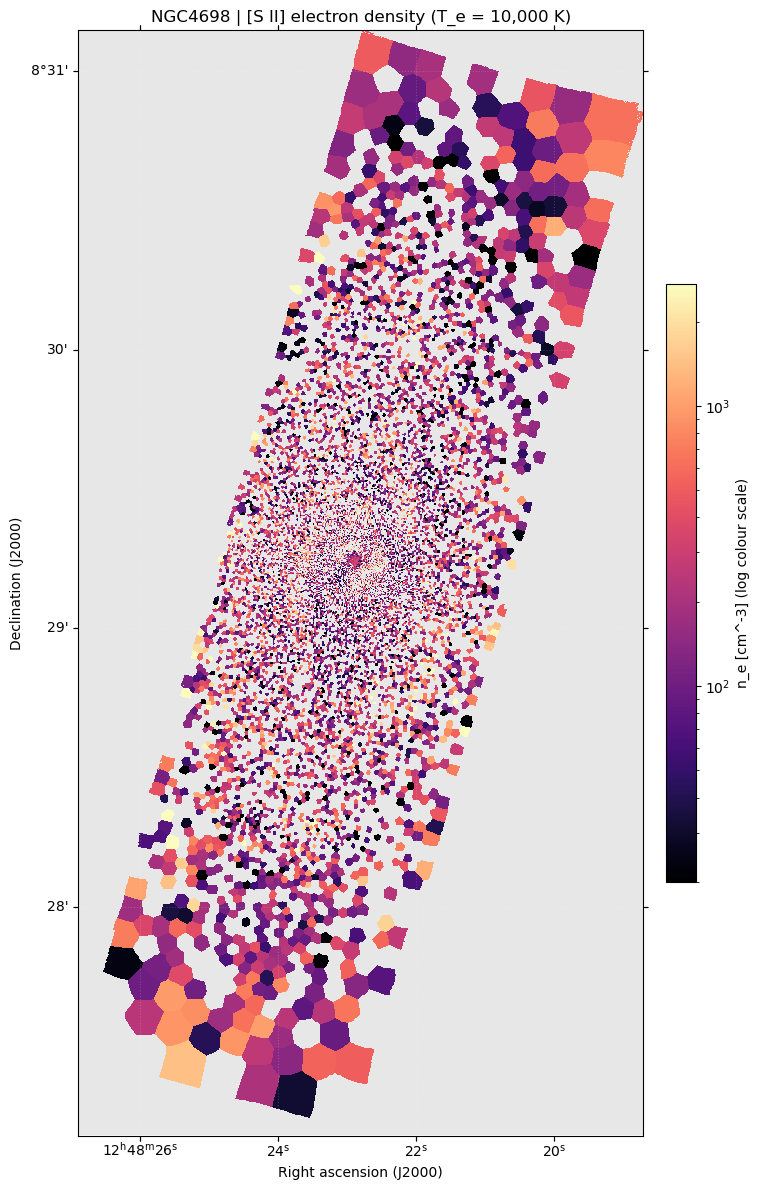

In [8]:
valid_ne = np.isfinite(ne_map)
if not np.any(valid_ne):
    raise ValueError("No finite electron densities to display")
vmax = max(1000.0, float(np.nanpercentile(ne_map[measured], 99)))
density_cmap = plt.get_cmap("magma").copy()
density_cmap.set_bad("#e7e7e7")

fig = plt.figure(figsize=(9, 12))
ax = fig.add_subplot(111, projection=wcs_6716)
image = ax.imshow(
    np.ma.masked_invalid(ne_map), origin="lower",
    cmap=density_cmap, norm=LogNorm(vmin=NE_MIN_CM3, vmax=vmax),
    interpolation="nearest",
)
ax.set_title("NGC4698 | [S II] electron density (T_e = 10,000 K)")
ax.coords[0].set_axislabel("Right ascension (J2000)")
ax.coords[1].set_axislabel("Declination (J2000)")
ax.coords.grid(color="white", alpha=0.18, linestyle=":")
colorbar = fig.colorbar(image, ax=ax, fraction=0.04, pad=0.03)
colorbar.set_label("n_e [cm^-3] (log colour scale)")
fig.tight_layout()
plt.show()

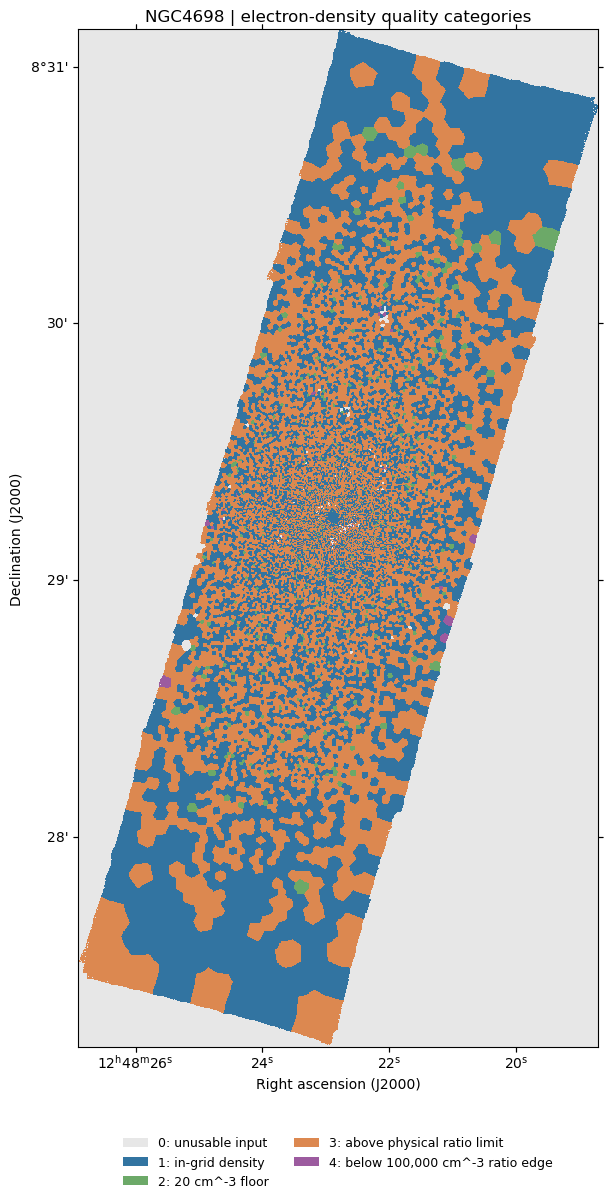

In [9]:
qc_colors = [
    "#e7e7e7",  # no usable input
    "#3274a1",  # in-grid measurement
    "#6ca968",  # 20 cm^-3 floor
    "#dc8850",  # above physical ratio limit
    "#9c5b9f",  # above high-density grid
]
qc_cmap = ListedColormap(qc_colors)
qc_norm = BoundaryNorm(np.arange(-0.5, 5.5, 1), qc_cmap.N)
fig = plt.figure(figsize=(9, 12))
ax = fig.add_subplot(111, projection=wcs_6716)
ax.imshow(qc, origin="lower", cmap=qc_cmap, norm=qc_norm,
          interpolation="nearest")
ax.set_title("NGC4698 | electron-density quality categories")
ax.coords[0].set_axislabel("Right ascension (J2000)")
ax.coords[1].set_axislabel("Declination (J2000)")
handles = [Patch(facecolor=qc_colors[i], label=f"{i}: {labels[i]}")
           for i in range(5)]
ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.15),
          ncol=2, frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

## 7. Construct and display `NE_SII_ALL`

As in the source notebook, `NE_SII_ALL` keeps finite density values and
assigns 20 cm$^{-3}$ to other pixels within the joint-finite [S II]
flux footprint. This footprint is a proxy for spatial usability, not the
`V_STARS2` mask used by `SFR+Z.py`. The source FITS file does contain
`V_STARS2`, but this notebook retains the source notebook's footprint rule
so the calculation changes only in its flux inputs.

`all_fill` marks newly assigned values; QC=2 marks the separate
low-density floor. Neither is an exact density measurement.


Joint-finite input footprint: 352,550
Finite NE_SII retained: 185,200
New 20 cm^-3 fallback values: 167,350
NE_SII_ALL finite pixels: 352,550
NE_SII_ALL pixels displayed at 20 cm^-3: 175,206


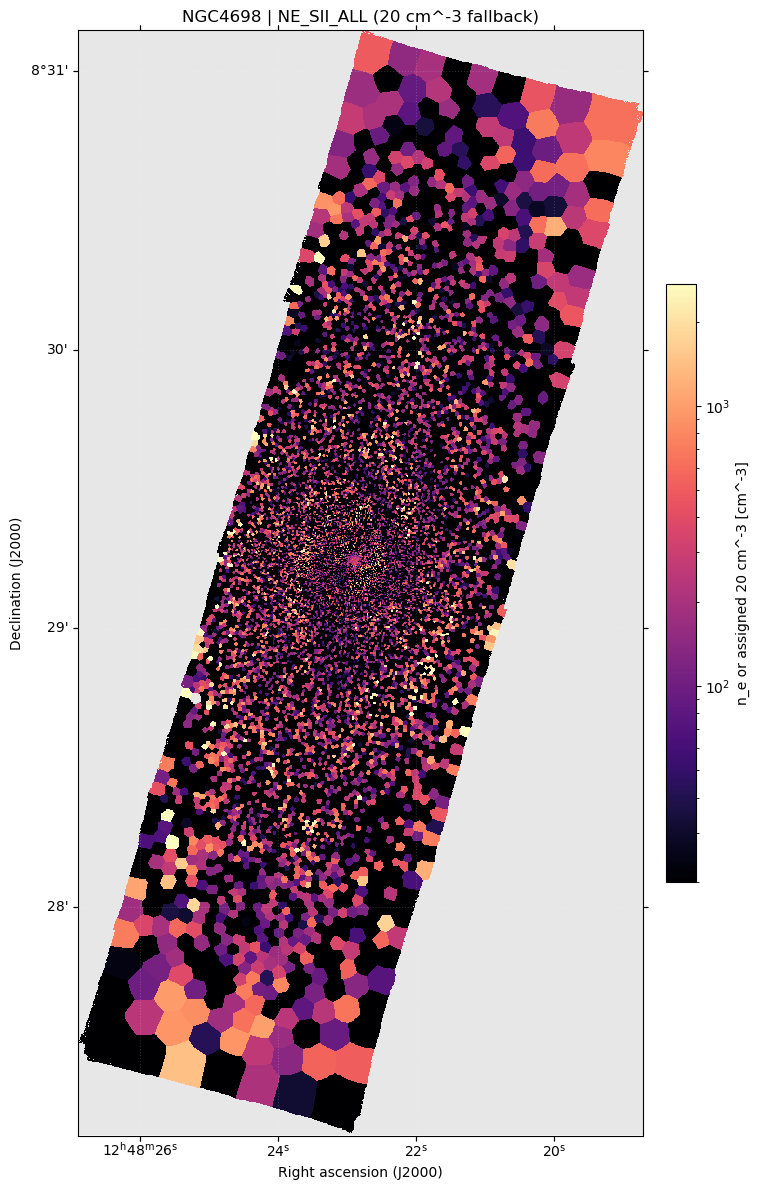

In [10]:
spatial_footprint = np.isfinite(flux_6716) & np.isfinite(flux_6731)
all_fill = spatial_footprint & ~np.isfinite(ne_map)
ne_all_map = np.where(
    spatial_footprint,
    np.where(np.isfinite(ne_map), ne_map, NE_MIN_CM3),
    np.nan,
)
if not np.array_equal(np.isfinite(ne_all_map), spatial_footprint):
    raise ValueError("NE_SII_ALL finite pixels do not match its footprint")
if not np.all(ne_all_map[all_fill] == NE_MIN_CM3):
    raise ValueError("NE_SII_ALL fill values are inconsistent")
if not np.allclose(
    ne_all_map[spatial_footprint & ~all_fill],
    ne_map[spatial_footprint & ~all_fill],
):
    raise ValueError("NE_SII_ALL changed a finite NE_SII value")

print(f"Joint-finite input footprint: {np.count_nonzero(spatial_footprint):,}")
print(f"Finite NE_SII retained: {np.count_nonzero(spatial_footprint & ~all_fill):,}")
print(f"New 20 cm^-3 fallback values: {np.count_nonzero(all_fill):,}")
print(f"NE_SII_ALL finite pixels: {np.count_nonzero(np.isfinite(ne_all_map)):,}")
print(f"NE_SII_ALL pixels displayed at 20 cm^-3: "
      f"{np.count_nonzero(ne_all_map == NE_MIN_CM3):,}")

fig = plt.figure(figsize=(9, 12))
ax = fig.add_subplot(111, projection=wcs_6716)
image = ax.imshow(
    np.ma.masked_invalid(ne_all_map), origin="lower",
    cmap=density_cmap, norm=LogNorm(vmin=NE_MIN_CM3, vmax=vmax),
    interpolation="nearest",
)
ax.set_title("NGC4698 | NE_SII_ALL (20 cm^-3 fallback)")
ax.coords[0].set_axislabel("Right ascension (J2000)")
ax.coords[1].set_axislabel("Declination (J2000)")
ax.coords.grid(color="white", alpha=0.18, linestyle=":")
colorbar = fig.colorbar(image, ax=ax, fraction=0.04, pad=0.03)
colorbar.set_label("n_e or assigned 20 cm^-3 [cm^-3]")
fig.tight_layout()
plt.show()